In [ ]:
import pandas as pd
import yfinance as yf
from pandas_datareader import data as pdr

# ---- Configuration ---- #
START_DATE = "2002-01-01"
END_DATE = "2021-12-31"
node=5

# ---- Functions ---- #
def fetch_yahoo_close(ticker: str, column_name: str, interval='1d') -> pd.DataFrame:
    df = yf.download(ticker, start=START_DATE, end=END_DATE, interval=interval, progress=False)
    df = df[['Close']].copy()
    df.columns = [column_name]  # Fix column name
    return df


def fetch_fred_series(series_code: str, column_name: str) -> pd.DataFrame:

    df = pdr.DataReader(series_code, 'fred', start=START_DATE, end=END_DATE)
    return df.rename(columns={series_code: column_name})

def resample_to_monthly(df: pd.DataFrame) -> pd.DataFrame:

    return df.resample('M').last()

# ---- Data Fetching ---- #
sp500 = fetch_yahoo_close('^GSPC', 'SP500_Close')
vix = fetch_yahoo_close('^VIX', 'VIX_Close')
tnx = fetch_yahoo_close('^TNX', 'TNX_Close')  # in %
tbill = fetch_fred_series('DTB3', 'TBill_Rate')  # in %

# ---- Combine into One DataFrame ---- #
market_data = sp500.join([vix, tnx, tbill], how='outer')
market_data = market_data.sort_index()

# ---- Optional: Get Monthly Data ---- #
market_data_monthly = resample_to_monthly(market_data)

# ---- Print Sample Output ---- #
print("🔹 Daily Data Sample:")
print(market_data.head(), "\n")

print("🔹 Monthly Data Sample:")
print(market_data_monthly.head())
# Clean column names to avoid hidden space or encoding issues
market_data_monthly.columns = market_data_monthly.columns.str.strip()
print(market_data_monthly.columns)

import numpy as np
import pandas as pd
from scipy.optimize import linprog

def build_arbitrage_free_tree(df, branching_structure, max_attempts=100):

    # 1. Compute fractional monthly returns for each asset
    returns_df = df.pct_change().dropna()

    # 2. Initialize the tree structure
    tree = {
        'nodes': {},
        'structure': branching_structure,
        'num_stages': len(branching_structure) + 1,
        'num_assets': len(df.columns)
    }

    # 3. Create root node
    tree['nodes'][0] = {
        'stage': 0,
        'parent': None,
        'children': [],
        'probability': 1.0,
        'returns': None
    }

    # 4. Generate the tree structure
    node_counter = 1
    for stage in range(1, tree['num_stages']):
        nodes_at_previous_stage = [n for n, node in tree['nodes'].items() if node['stage'] == stage - 1]

        for parent_node_id in nodes_at_previous_stage:
            parent_node = tree['nodes'][parent_node_id]
            branching_degree = branching_structure[stage - 1]

            # Sample returns and check for absence of arbitrage
            for attempt in range(max_attempts):
                # Sample returns from historical data
                sampled_indices = np.random.choice(len(returns_df), size=branching_degree, replace=True)
                sampled_returns = returns_df.iloc[sampled_indices][df.columns].values


                # Check for absence of arbitrage
                if check_no_arbitrage(sampled_returns, riskfree_idx=len(df.columns)-1):
                    # Create child nodes with these returns
                    for i, returns in enumerate(sampled_returns):
                        tree['nodes'][node_counter] = {
                            'stage': stage,
                            'parent': parent_node_id,
                            'children': [],
                            'probability': parent_node['probability'] / branching_degree,
                            'returns': returns
                        }

                        # Add child to parent's children list
                        parent_node['children'].append(node_counter)
                        node_counter += 1

                    break

                if attempt == max_attempts - 1:
                    raise RuntimeError(f"Failed to find arbitrage-free returns for node {parent_node_id} after {max_attempts} attempts")
    # Assign full_prob to each node based on parent-child relationships
    tree['nodes'][0]['full_prob'] = 1.0  # root node

    for nid, node in tree['nodes'].items():
        if node['parent'] is not None:
            parent = tree['nodes'][node['parent']]
            node['full_prob'] = parent['full_prob'] * (node['probability'] / parent['probability'])


    return tree

def check_no_arbitrage(returns, riskfree_idx=-1):
    num_scenarios, num_assets = returns.shape

    A_eq = []
    b_eq = []

    # Constraint: sum of probabilities = 1
    A_eq.append([1.0] * num_scenarios)
    b_eq.append(1.0)

    # For each asset (except risk-free), enforce no-arbitrage
    for i in range(num_assets):
        if i == riskfree_idx:
            continue
        coeffs = []
        for j in range(num_scenarios):
            r_ij = returns[j, i]
            r_rf = returns[j, riskfree_idx]
            coeffs.append((1 + r_ij) / (1 + r_rf))
        A_eq.append(coeffs)
        b_eq.append(1.0)

    A_eq = np.array(A_eq)
    b_eq = np.array(b_eq)
    bounds = [(1e-10, None)] * num_scenarios
    c = np.ones(num_scenarios)

    try:
        result = linprog(c, A_eq=A_eq, b_eq=b_eq, bounds=bounds, method='highs')
        return result.success
    except Exception as e:
        print(f"Error in linprog: {e}")
        return False



# Example usage:
scenario_tree = build_arbitrage_free_tree(market_data_monthly,[node,node,node])
print(scenario_tree)
def scenario_tree_to_dataframe(tree):
    """
    Convert the scenario tree dictionary to a pandas DataFrame for easy viewing.
    """
    data = []
    for node_id, node in tree['nodes'].items():
        data.append({
            'id': node_id,
            'stage': node['stage'],
            'parent': node['parent'],
            'probability': node['probability'],
            'returns': node['returns'],
            'risk_neutral_prob': node.get('risk_neutral_prob', None)
        })
    return pd.DataFrame(data).sort_values(by=['stage', 'parent', 'id']).reset_index(drop=True)

# Convert and print


def calculate_risk_neutral_measure(tree, risk_free_rates):
    """
    Assign MEMM-based risk-neutral probabilities to each node in the scenario tree.
    """
    for stage in range(1, tree['num_stages']):
        parents = [nid for nid, node in tree['nodes'].items() if node['stage'] == stage - 1]

        for pid in parents:
            parent = tree['nodes'][pid]
            children_ids = parent['children']

            if not children_ids or any(tree['nodes'][cid]['returns'] is None for cid in children_ids):
                continue

            child_returns = np.array([tree['nodes'][cid]['returns'] for cid in children_ids])

            # ✅ Correct empirical conditional probabilities from full path
            real_world_probs = np.array([
                tree['nodes'][cid]['full_prob'] / parent['full_prob']
                for cid in children_ids
            ])

            rf = risk_free_rates[stage - 1]
            risk_neutral_probs = compute_minimal_entropy_measure(child_returns, real_world_probs, rf)

            for i, cid in enumerate(children_ids):
                tree['nodes'][cid]['risk_neutral_prob'] = risk_neutral_probs[i]

    return tree
def compute_minimal_entropy_measure(returns, p, risk_free_rate):
    """
    Compute MEMM-based risk-neutral probabilities using KL divergence minimization.
    """
    num_scenarios, num_assets = returns.shape
    R = 1 + risk_free_rate  # risk-free gross return

    # Objective: Relative entropy (KL divergence)
    def objective(q):
        eps = 1e-12
        return np.sum(q * np.log(np.clip(q / (p + eps), eps, None)))

    # Initial guess
    q0 = np.copy(p)
    q0 = np.clip(q0, 1e-10, 1.0)
    q0 /= np.sum(q0)

    # Constraints
    constraints = [{'type': 'eq', 'fun': lambda q: np.sum(q) - 1.0}]
    for i in range(num_assets):
        constraints.append({
            'type': 'eq',
            'fun': lambda q, i=i: np.dot(q, (1 + returns[:, i])) - R
        })

    bounds = [(1e-10, 1.0) for _ in range(num_scenarios)]

    result = minimize(objective, q0, bounds=bounds, constraints=constraints, method='SLSQP')

    if not result.success:
        print("⚠️ MEMM optimization failed:", result.message)
        return p  # fallback to physical probabilities

    return result.x
from scipy.optimize import minimize
import numpy as np
np.random.seed(42)

tree = build_arbitrage_free_tree(market_data_monthly,[node,node,node])
risk_free_rates = market_data_monthly['TBill_Rate'].values[:tree['num_stages']-1] / 100  # convert from %
tree = calculate_risk_neutral_measure(tree, risk_free_rates)
df = scenario_tree_to_dataframe(tree)
print(df[['id', 'stage', 'returns', 'probability', 'risk_neutral_prob']])
class EuropeanOption:
    def __init__(self, strike, maturity_stage, option_type='call', asset_index=0):
        self.strike = strike
        self.maturity_stage = maturity_stage  # which stage the option expires
        self.option_type = option_type.lower()
        self.asset_index = asset_index  # which asset (e.g., S&P500 index)

    def payoff(self, asset_price):
        if self.option_type == 'call':
            return max(asset_price - self.strike, 0)
        elif self.option_type == 'put':
            return max(self.strike - asset_price, 0)
        else:
            raise ValueError("Invalid option type: must be 'call' or 'put'")
initial_price = market_data_monthly['SP500_Close'].dropna().iloc[-1]

options = [
    EuropeanOption(strike=initial_price * 1.0, maturity_stage=2, option_type='call'),
    EuropeanOption(strike=initial_price * , maturity_stage=3, option_type='put'),
    EuropeanOption(strike=initial_price * 1.05, maturity_stage=3, option_type='call'),
]
def enrich_tree_with_option_prices(tree, options, initial_price):
    for opt_idx, option in enumerate(options):
        # Step 1: Compute option payoff at expiry nodes
        option_values = {}
        for nid, node in tree['nodes'].items():
            if node['stage'] == option.maturity_stage:
                asset_return = np.prod([
                    1 + tree['nodes'][ancestor]['returns'][option.asset_index]
                    for ancestor in get_ancestor_path(tree, nid)
                    if tree['nodes'][ancestor]['returns'] is not None
                ])
                final_price = initial_price * asset_return
                option_values[nid] = option.payoff(final_price)

        # Step 2: Backward recursion to price the option
        for stage in reversed(range(option.maturity_stage)):
            for nid, node in tree['nodes'].items():
                if node['stage'] == stage:
                    children = node['children']
                    if not children:
                        continue
                    q = np.array([tree['nodes'][cid]['risk_neutral_prob'] for cid in children])
                    v = np.array([option_values.get(cid, 0.0) for cid in children])
                    option_values[nid] = np.dot(q, v)

        # Step 3: Store option values at all nodes
        for nid in tree['nodes']:
            tree['nodes'][nid][f'option_{opt_idx}_value'] = option_values.get(nid, 0.0)

    return tree
def get_ancestor_path(tree, node_id):
    """
    Returns a list of node IDs from root to the given node (inclusive).
    """
    path = []
    while node_id is not None:
        path.insert(0, node_id)
        node_id = tree['nodes'][node_id]['parent']
    return path

# After risk-neutral probabilities are calculated
tree = enrich_tree_with_option_prices(tree, options, initial_price)
print("Option values at t=0 (root):")
for i, option in enumerate(options):
    print(f"Option {i} (type={option.option_type}, strike={option.strike}, maturity={option.maturity_stage}):",
          tree['nodes'][0][f'option_{i}_value'])
market_data_monthly.to_csv("market_data_monthly.csv")


<ipython-input-47-446743322>:25: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  return df.resample('M').last()


🔹 Daily Data Sample:
            SP500_Close  VIX_Close  TNX_Close  TBill_Rate
2002-01-01          NaN        NaN        NaN         NaN
2002-01-02  1154.670044  22.709999      5.157        1.71
2002-01-03  1165.270020  21.340000      5.120        1.70
2002-01-04  1172.510010  20.450001      5.141        1.69
2002-01-07  1164.890015  21.940001      5.057        1.66 

🔹 Monthly Data Sample:
            SP500_Close  VIX_Close  TNX_Close  TBill_Rate
2002-01-31  1130.199951      21.09      5.025        1.73
2002-02-28  1106.729980      21.59      4.859        1.76
2002-03-31  1147.390015      17.40      5.406        1.76
2002-04-30  1076.920044      21.91      5.091        1.74
2002-05-31  1067.140015      19.98      5.043        1.71
Index(['SP500_Close', 'VIX_Close', 'TNX_Close', 'TBill_Rate'], dtype='object')
{'nodes': {0: {'stage': 0, 'parent': None, 'children': [1, 2, 3, 4, 5], 'probability': 1.0, 'returns': None, 'full_prob': 1.0}, 1: {'stage': 1, 'parent': 0, 'children': [6, 7, 8, 

/usr/local/lib/python3.11/dist-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit reached
⚠️ MEMM optimization failed: Iteration limit r

In [ ]:
import numpy as np

# -------- Flatten Tree Step -------- #
def flatten_tree(tree):
    """
    Converts scenario tree to flattened arrays for optimization.
    Returns a dict with key arrays.
    """
    node_ids = list(tree['nodes'].keys())
    num_nodes = len(node_ids)

    stage_arr = np.zeros(num_nodes, dtype=int)
    parent_arr = np.full(num_nodes, -1, dtype=int)
    prob_arr = np.zeros(num_nodes)
    full_prob_arr = np.zeros(num_nodes)
    return_arr = [None] * num_nodes
    option_cash = np.zeros(num_nodes)

    node_id_to_idx = {nid: idx for idx, nid in enumerate(node_ids)}
    idx_to_node_id = {idx: nid for nid, idx in node_id_to_idx.items()}

    for idx, nid in enumerate(node_ids):
        node = tree['nodes'][nid]
        stage_arr[idx] = node['stage']
        parent_arr[idx] = node_id_to_idx.get(node['parent'], -1) if node['parent'] is not None else -1
        prob_arr[idx] = node['probability']
        full_prob_arr[idx] = node['full_prob']
        return_arr[idx] = node['returns']
        # Sum of option values at this node
        option_keys = [k for k in node if k.startswith('option_') and k.endswith('_value')]
        option_cash[idx] = sum([node[k] for k in option_keys])

    return {
        'stage_arr': stage_arr,
        'parent_arr': parent_arr,
        'prob_arr': prob_arr,
        'full_prob_arr': full_prob_arr,
        'return_arr': np.vstack([r if r is not None else np.zeros(tree['num_assets']) for r in return_arr]),
        'option_cash': option_cash,
        'node_ids': np.array(node_ids),
        'node_id_to_idx': node_id_to_idx,
        'idx_to_node_id': idx_to_node_id
    }

# Apply to current tree
flat_tree = flatten_tree(tree)
flat_tree.keys()
def get_decision_nodes(flat_tree, tree):
    """
    Identify ALL non-terminal nodes (including root) where decisions are made.
    """
    is_terminal = np.array([
        len(tree['nodes'][nid].get('children', [])) == 0
        for nid in flat_tree['node_ids']
    ])
    decision_mask = ~is_terminal  # Include root if it has children
    return np.where(decision_mask)[0]


# Step 3: Wealth propagation (forward pass given X allocations)
def propagate_wealth(flat_tree, X, tree_structure):
    """
    Given flat_tree and decision allocations X, propagate wealth to all nodes.
    Returns wealth array W for all nodes.
    """
    num_nodes = len(flat_tree['node_ids'])
    num_assets = tree_structure['num_assets']
    W = np.zeros(num_nodes)
    W[0] = 100000.0  # Initial wealth at root

    # Mapping from node index to X row (allocation)
    allocation_idx_map = {}

    # Identify nodes where decisions are made
    decision_nodes = []
    for i, nid in enumerate(flat_tree['node_ids']):
        children = tree_structure['nodes'][nid].get('children', [])
        if children:
            decision_nodes.append(i)
            allocation_idx_map[i] = len(allocation_idx_map)

    for i in range(1, num_nodes):
        parent_idx = flat_tree['parent_arr'][i]
        if parent_idx == -1:
            continue
        r = flat_tree['return_arr'][i]
        option_val = flat_tree['option_cash'][i]

        if parent_idx in allocation_idx_map:
            x = X[allocation_idx_map[parent_idx]]
        else:
            x = np.full(num_assets, 1.0 / num_assets)

        W[i] = W[parent_idx] * (1 + np.dot(x, r)) + option_val

    return W

# Display decision node indices
decision_node_indices = get_decision_nodes(flat_tree, tree)
def expected_terminal_wealth(X_vector, flat_tree, decision_node_indices, tree):
    """
    Objective function: negative expected terminal wealth (for minimization).
    """
    num_assets = tree['num_assets']
    X = X_vector.reshape(len(decision_node_indices), num_assets)

    # Propagate wealth across the tree
    W = propagate_wealth(flat_tree, X, tree)

    # Identify terminal nodes (no children)
    terminal_indices = [i for i, nid in enumerate(flat_tree['node_ids'])
                        if not tree['nodes'][nid].get('children')]

    # Compute mean terminal wealth
    expected_wealth = np.mean([W[i] for i in terminal_indices])

    return -expected_wealth  # negative for minimization
from scipy.optimize import minimize

num_decision_nodes = len(decision_node_indices)
num_assets = tree['num_assets']

constraints = []
for i in range(num_decision_nodes):
    constraints.append({
        'type': 'eq',
        'fun': lambda x, i=i: np.sum(x[i*num_assets:(i+1)*num_assets]) - 1
    })
bounds = [(0.0, 1.0)] * (num_decision_nodes * num_assets)
x0 = np.full(num_decision_nodes * num_assets, 1.0 / num_assets)
result = minimize(
    expected_terminal_wealth,
    x0,
    args=(flat_tree, decision_node_indices, tree),
    bounds=bounds,
    constraints=constraints,
    method='SLSQP',
    options={'disp': True, 'maxiter': 500}
)
# Reshape X to 2D allocation matrix
X_optimal = result.x.reshape(num_decision_nodes, num_assets)

# Get wealth at all nodes using the optimal allocation
wealth_at_nodes = propagate_wealth(flat_tree, X_optimal, tree)

# Print wealth at each node, grouped by stage
# for stage in range(flat_tree['stage_arr'].max() + 1):
#     print(f"\n📊 Stage {stage}")
#     for i, node_id in enumerate(flat_tree['node_ids']):
#         if flat_tree['stage_arr'][i] == stage:
#             print(f"Node {node_id:3}: Wealth = {wealth_at_nodes[i]:.4f}")
df = scenario_tree_to_dataframe(tree)
df.to_csv("scenario_tree.csv", index=False)


Positive directional derivative for linesearch    (Exit mode 8)
            Current function value: -132007.02716454683
            Iterations: 9
            Function evaluations: 625
            Gradient evaluations: 5



🔹 Optimized Strategy:
   ✅ Expected Terminal Wealth: 132007.03
   📉 Std Dev: 124693.84
   ⬇️ Min: 29577.71
   ⬆️ Max: 1098474.47


<ipython-input-46-2854004505>:56: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


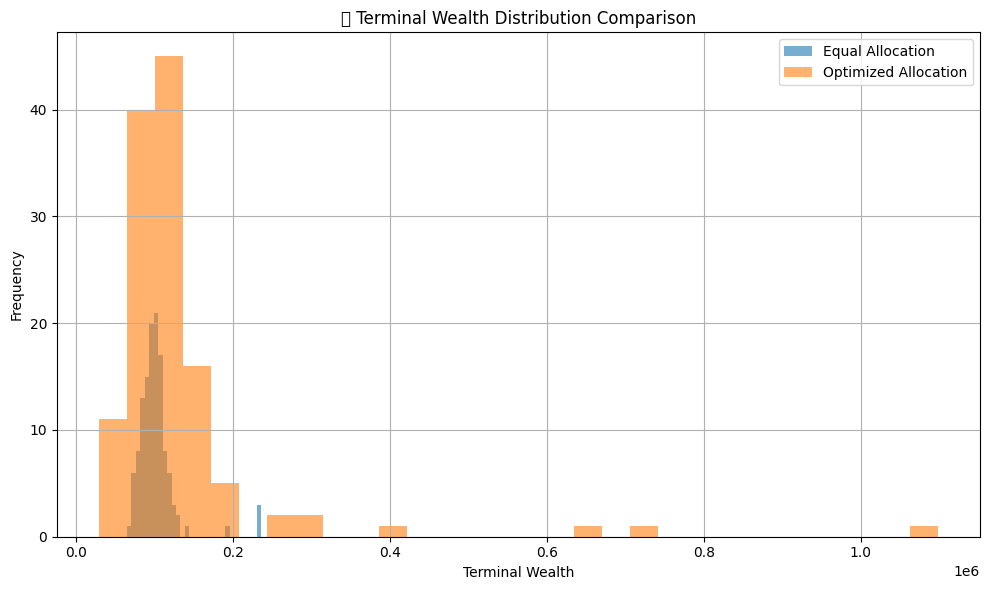

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ---------------------- Equal Allocation Strategy ---------------------- #
num_assets = tree['num_assets']
num_decision_nodes = len(decision_node_indices)

# Create equal allocation: [1/n, 1/n, ..., 1/n]
equal_allocation = np.full(num_assets, 1.0 / num_assets)
X_equal = np.tile(equal_allocation, (num_decision_nodes, 1))  # shape: (num_decision_nodes, num_assets)

# Propagate wealth through scenario tree
wealth_equal = propagate_wealth(flat_tree, X_equal, tree)

# Get terminal nodes
terminal_indices = [i for i, nid in enumerate(flat_tree['node_ids']) if not tree['nodes'][nid].get('children')]

# Compute statistics for equal allocation
equal_wealths = [wealth_equal[i] for i in terminal_indices]
expected_wealth_equal = np.mean(equal_wealths)
std_wealth_equal = np.std(equal_wealths)
min_wealth_equal = np.min(equal_wealths)
max_wealth_equal = np.max(equal_wealths)

# print("\n🔸 Equal Allocation Strategy:")
# print(f"   ✅ Expected Terminal Wealth: {expected_wealth_equal:.2f}")
# print(f"   📉 Std Dev: {std_wealth_equal:.2f}")
# print(f"   ⬇️ Min: {min_wealth_equal:.2f}")
# print(f"   ⬆️ Max: {max_wealth_equal:.2f}")

# ---------------------- Optimized Strategy ---------------------- #
X_optimal = result.x.reshape(num_decision_nodes, num_assets)
wealth_opt = propagate_wealth(flat_tree, X_optimal, tree)

opt_wealths = [wealth_opt[i] for i in terminal_indices]
expected_wealth_opt = np.mean(opt_wealths)
std_wealth_opt = np.std(opt_wealths)
min_wealth_opt = np.min(opt_wealths)
max_wealth_opt = np.max(opt_wealths)

print("\n🔹 Optimized Strategy:")
print(f"   ✅ Expected Terminal Wealth: {expected_wealth_opt:.2f}")
print(f"   📉 Std Dev: {std_wealth_opt:.2f}")
print(f"   ⬇️ Min: {min_wealth_opt:.2f}")
print(f"   ⬆️ Max: {max_wealth_opt:.2f}")

# ---------------------- Optional Plot ---------------------- #
plt.figure(figsize=(10, 6))
plt.hist(equal_wealths, bins=30, alpha=0.6, label='Equal Allocation')
plt.hist(opt_wealths, bins=30, alpha=0.6, label='Optimized Allocation')
plt.xlabel('Terminal Wealth')
plt.ylabel('Frequency')
plt.title('📊 Terminal Wealth Distribution Comparison')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
